# Health Insurance Lead Prediction: Predictive Modeling

In this notebook, we will use the cleaned dataset to train a machine learning classification model. We will evaluate its performance and extract the most important features that drive customer conversion.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load cleaned dataset
df = pd.read_csv('../data/processed/cleaned_health_insurance.csv')
print(f"Cleaned dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")


Cleaned dataset loaded with 50882 rows and 16 columns.


In [2]:
# Preprocessing
# Drop ID column as it's not a predictor
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
elif 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Separate categorical and numerical features
categorical_cols = df.select_dtypes(include=['object']).columns

# Encode categorical variables using Label Encoding for tree-based models
le = LabelEncoder()
for col in categorical_cols:
    # Convert everything to string first to avoid mixed type errors
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

df.head()


,City_Code,Region_Code,Accomodation_Type,Reco_Insurance_Type,Upper_Age,Lower_Age,Is_Spouse,Health Indicator,Holding_Policy_Duration,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response,Column1,Unnamed: 15
0,22,3213.0,1,0,36.0,36.0,0,0,14.0,3.0,22.0,11628.0,0.0,1.0,NaN
1,31,1117.0,0,1,75.0,22.0,0,1,0.0,NaN,22.0,30510.0,0.0,1.0,NaN
2,31,3732.0,0,0,32.0,32.0,0,0,1.0,1.0,19.0,7450.0,1.0,1.0,NaN
3,16,4378.0,0,1,52.0,48.0,0,0,14.0,3.0,19.0,17780.0,0.0,1.0,NaN
4,34,2190.0,1,0,44.0,44.0,0,1,3.0,1.0,16.0,10404.0,0.0,1.0,NaN


In [3]:
# Train-Test Split
X = df.drop('Response', axis=1)
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")


Training set: (40705, 14)
Testing set: (10177, 14)


In [4]:
# Model Training (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]


Classification Report:

              precision    recall  f1-score   support

         0.0       0.84      0.28      0.42      7735
         1.0       0.27      0.84      0.41      2442

    accuracy                           0.41     10177
   macro avg       0.56      0.56      0.41     10177
weighted avg       0.71      0.41      0.42     10177

ROC-AUC Score: 0.5899


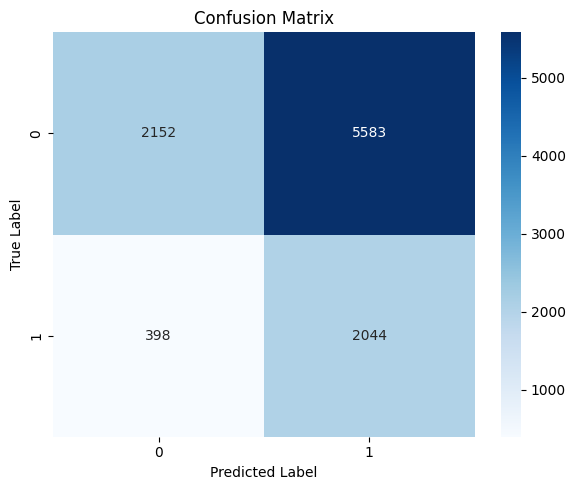

In [5]:
# Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('../visualizations/confusion_matrix.png', dpi=300)
plt.show()


C:\Users\nshar\AppData\Local\Temp\ipykernel_17880\1370804470.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


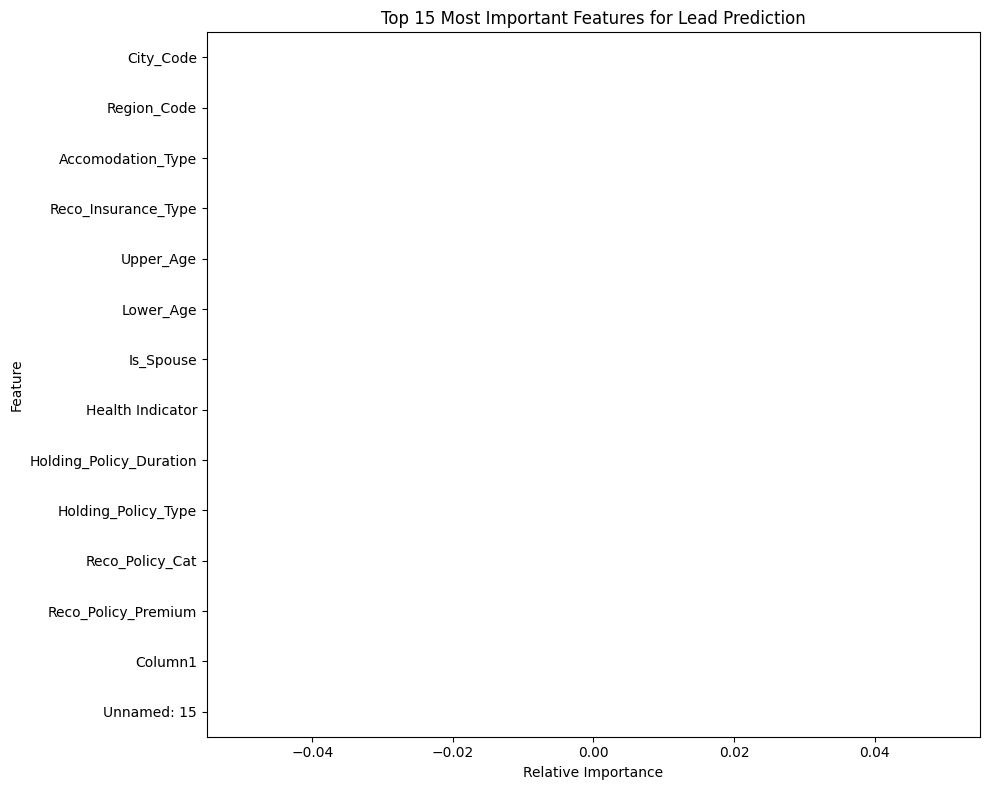

In [6]:
# Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df.head(15), palette='viridis', legend=False)
plt.title('Top 15 Most Important Features for Lead Prediction')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../visualizations/feature_importance.png', dpi=300)
plt.show()
